# SECTION 1: Introduction

This notebook includes all the causal and counterfactual analysis performed on the causal graph, generated from "TASK_5/causal_graph.py", using DoWhy and NetworkX. The main dataset that is being used for this analysis is all 12,672 rows from "TASK_3_4/experiment_results.csv" file, which
is then split into two different GCM models, one model covering all outcome metrics except success_probability (fit on the full dataset), and a second Grover-specific model covering success_probability (fit on Grover-only rows). This is done to avoid NaN issues from success_probability being undefined for four of the five circuit types. The following are the five main questions that this file serves to answer:

1) Does increasing circuit depth cause a measurable decrease in output quality under a fixed noise model?
2) Does Qiskit’s transpilation optimization level reduce gate count or circuit depth enough to improve output quality?
3) How does the number of shots affect the stability of the measured output distribution?
4) Which has a stronger effect on output quality: circuit depth, two-qubit gate count, or simulated noise rate?
5) Can a simple causal graph help explain how quantum workflow configurations influence observed out-
comes?

# SECTION 2: Setup Code

### Setting Up The Causal Graph

In [39]:
import sys
import os
sys.path.append(os.path.join(os.path.dirname("TASK_6"), '..', 'TASK_5'))
%matplotlib inline

from dowhy import gcm
import pandas as pd
from causal_graph import get_nx
from IPython.display import Image
import random
import numpy as np

random.seed(42)
np.random.seed(42)

graph_1 = get_nx(only_sp=False) # all edges without success_probability
graph_2 = get_nx(only_sp=True) # all edges with only success_probability

# load general data_file
data_file = pd.read_csv('C:/Users/vigne/Qiskit/AISys_QC_Exploring_Casualty/TASK_3_4/experiment_results.csv')

# initialize two different models for avoiding NaN error
main_model = gcm.StructuralCausalModel(graph_1)
grover_model = gcm.StructuralCausalModel(graph_2)

### Initializing Two Different Models & Fitting Both Models

Two separate causal graphs are constructed - one for the main model (all outcomes except `success_probability`) and one for the Grover-specific model (`success_probability` only). This split is necessary because `success_probability` is only defined for the Grover circuit, resulting in NaN values for the other four circuit types across ~83% of rows.

In [40]:
# then initialize two seperate files for the two different models initialized earlier
grover_df = data_file[data_file['circuit_name'] == 'Grover'][list(graph_2.nodes)]
main_df = data_file[list(graph_1.nodes)]

# assign each of the model to causal mechanisms
gcm.auto.assign_causal_mechanisms(main_model, main_df)
gcm.auto.assign_causal_mechanisms(grover_model, grover_df)


# # print out the node --> causal_mechanism
for node in main_model.graph.nodes:
    print(node, "-->", main_model.causal_mechanism(node))

print("\n", "------------------", "\n")

for node in grover_model.graph.nodes:
    print(node, "-->", grover_model.causal_mechanism(node))

# fitting the data from the two different models, for analysis
gcm.fit(main_model, main_df)
gcm.fit(grover_model, grover_df)

shots --> Empirical Distribution
tvd --> AdditiveNoiseModel using HistGradientBoostingRegressor
optimization_level --> Empirical Distribution
depth --> Discrete AdditiveNoiseModel using HistGradientBoostingRegressor
count_2q --> Discrete AdditiveNoiseModel using HistGradientBoostingRegressor
noise_rate --> Empirical Distribution
num_qubits --> Empirical Distribution
runtime --> AdditiveNoiseModel using LinearRegression
circuit_name --> Empirical Distribution

 ------------------ 

noise_rate --> Empirical Distribution
success_probability --> AdditiveNoiseModel using HistGradientBoostingRegressor
depth --> Empirical Distribution
count_2q --> Empirical Distribution


Fitting causal mechanism of node count_2q: 100%|██████████| 4/4 [00:00<00:00,  7.75it/s]           


In [41]:
graph_1 = get_nx(only_sp=False)  # main graph: all edges without success_probability
graph_2 = get_nx(only_sp=True)   # grover graph: success_probability only

print("Main graph nodes:", list(graph_1.nodes))
print("Grover graph nodes:", list(graph_2.nodes))

Main graph nodes: ['shots', 'tvd', 'optimization_level', 'depth', 'count_2q', 'noise_rate', 'num_qubits', 'runtime', 'circuit_name']
Grover graph nodes: ['noise_rate', 'success_probability', 'depth', 'count_2q']


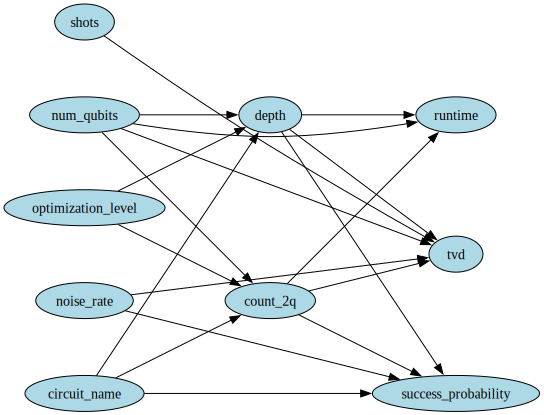

In [42]:
import graphviz
from IPython.display import SVG
import os
os.environ["PATH"] += os.pathsep + r"C:/Program Files/Graphviz/bin"

# create display-only unified graph (not used for fitting)
display_graph = graph_1.copy()
display_graph.add_edges_from([
    ("noise_rate", "success_probability"),
    ("depth", "success_probability"),
    ("count_2q", "success_probability"),
    ("circuit_name", "success_probability")
])

g = graphviz.Digraph(engine='neato')
g.attr(size='10,6')
g.attr(overlap='false')
g.attr(splines='true')
g.attr('node', shape='ellipse', style='filled', fillcolor='lightblue')

positions = {
    "shots":               "0,8!",
    "num_qubits":          "0,6!",
    "optimization_level":  "0,4!",
    "noise_rate":          "0,2!",
    "circuit_name":        "0,0!",
    "depth":               "4,6!",
    "count_2q":            "4,2!",
    "runtime":             "8,6!",
    "tvd":                 "8,3!",
    "success_probability": "8,0!"
}

for node, pos in positions.items():
    g.node(node, pos=pos)

for source, target in display_graph.edges():
    g.edge(source, target)

g.format = 'svg'
svg_data = g.pipe(encoding='utf-8')
SVG(svg_data)

# SECTION 3: Causal Analysis

The following section answers each of the five research questions using `gcm.arrow_strength()`, supporting charts, and the causal graph structure. `gcm.arrow_strength(model, target_node='X')` quantifies how strongly each parent node influences the target node `X`, by measuring how much the target's variance increases when each parent's contribution is replaced with noise.

### Question 1: Does increasing circuit depth cause a measurable decrease in output quality under a fixed noise model?

**Evidence components:**
1. `gcm.arrow_strength()` result for `depth → tvd`
2. "Variable Depth: TVD vs Circuit Depth, by Noise Level" chart
3. `depth → tvd` edge in the causal graph (shown in cell 22 above)

In [43]:
from joblib import parallel_backend

with parallel_backend('sequential'):
    tvd_strength = gcm.arrow_strength(main_model, target_node='tvd')

# the following is to convert np.float64() to float, and then sort it in decending order
ordered_tvd_strength = {}
for key, val in tvd_strength.items():
    ordered_tvd_strength[key] = float(val)


ordered_tvd_strength = dict(sorted(ordered_tvd_strength.items(), key=lambda item: item[1], reverse=True))

print("Arrow strengths into TVD (ranked):")
for (source, target), strength in ordered_tvd_strength.items():
    print(f"  {source} -> {target}: {strength:.6f}")

depth_key, depth_value = list(ordered_tvd_strength.items())[1]
print()
print("[", depth_key[0], " -> ", depth_key[1], "] : ", depth_value)

Arrow strengths into TVD (ranked):
  noise_rate -> tvd: 0.012467
  depth -> tvd: 0.003748
  count_2q -> tvd: 0.002059
  num_qubits -> tvd: 0.000568
  shots -> tvd: 0.000281

[ depth  ->  tvd ] :  0.0037477004347607566


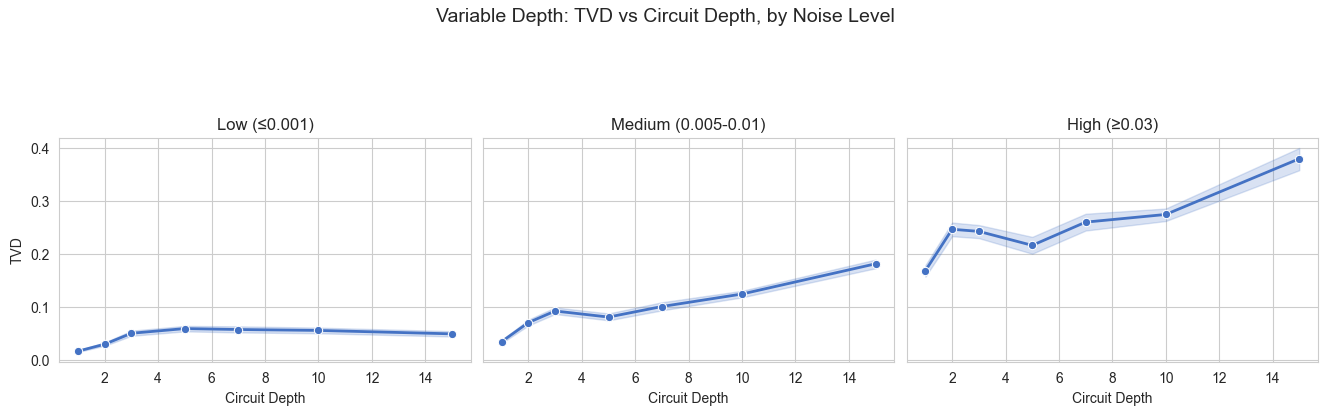

In [44]:
Image("../MATPLOTLIB_RESULTS/Variable Depth - TVD vs Circuit Depth, by Noise Level.png")

**Interpretation:** Increasing circuit depth causes a measurable increase in TVD (decrease in output quality). The `gcm.arrow_strength()` result confirms that `depth → tvd` is the **second strongest** causal influence on TVD out of all five incoming causes. The "Variable Depth: TVD vs Circuit Depth, by Noise Level" chart reinforces the direction of this effect: under all three noise levels, TVD increases as circuit depth increases, with the effect becoming most pronounced under high noise (≥0.03), where TVD climbs from ~0.16 at depth 1 to ~0.38 at depth 15. Together, the causal graph edge, the arrow strength ranking, and the chart confirm that deeper circuits accumulate more noise-induced error before measurement, causing a consistent and measurable decrease in output quality.

### Question 2: Does Qiskit's transpilation optimization level reduce gate count or circuit depth enough to improve output quality?

**Evidence components:**
1. `gcm.arrow_strength()` for `depth` and `count_2q` as target nodes - shows how weakly `optimization_level` influences the mediators compared to `circuit_name` and `num_qubits`
2. "Transpiled Depth by Optimization Level" chart
3. "Two-Qubit Gate Count by Optimization Level" chart
4. "TVD by Two-Qubit Gate Count, All Circuits" chart
5. "TVD by Transpiled Depth, All Circuits" chart

In [45]:
from joblib import parallel_backend

with parallel_backend('sequential'):
    depth_strength = gcm.arrow_strength(main_model, target_node='depth')

with parallel_backend('sequential'):    
    count_2q_strength = gcm.arrow_strength(main_model, target_node='count_2q')

print("Arrow strengths into depth (ranked):")
for (source, target), strength in sorted(depth_strength.items(), key=lambda x: x[1], reverse=True):
    print(f"  {source} -> {target}: {float(strength):.4f}")

print("\nArrow strengths into count_2q (ranked):")
for (source, target), strength in sorted(count_2q_strength.items(), key=lambda x: x[1], reverse=True):
    print(f"  {source} -> {target}: {float(strength):.4f}")

Arrow strengths into depth (ranked):
  circuit_name -> depth: 195.6133
  num_qubits -> depth: 76.8746
  optimization_level -> depth: 1.9452

Arrow strengths into count_2q (ranked):
  circuit_name -> count_2q: 62.9655
  num_qubits -> count_2q: 37.0142
  optimization_level -> count_2q: 0.3337


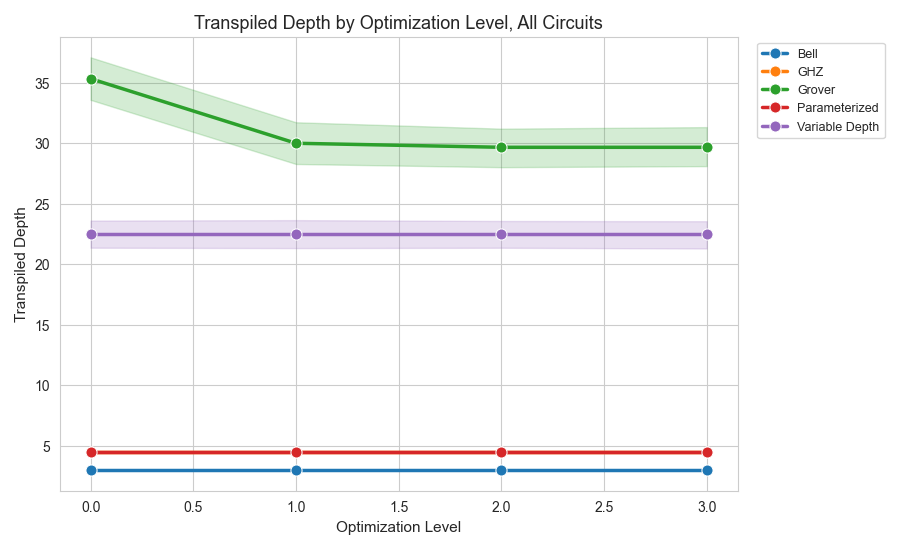

In [46]:
Image("../MATPLOTLIB_RESULTS/Transpiled Depth by Optimization Level, All Circuits.png")

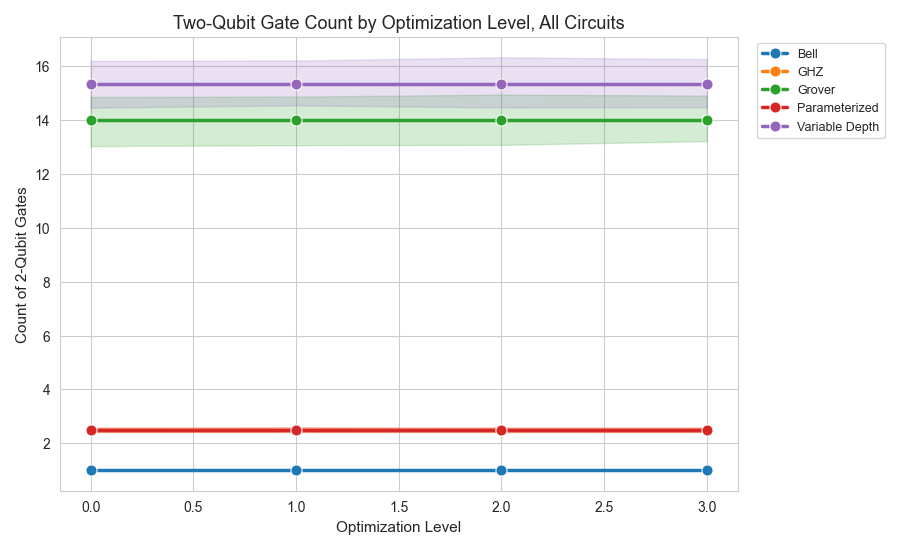

In [47]:
Image("../MATPLOTLIB_RESULTS/Two-Qubit Gate Count by Optimization Level, All Circuits.png")

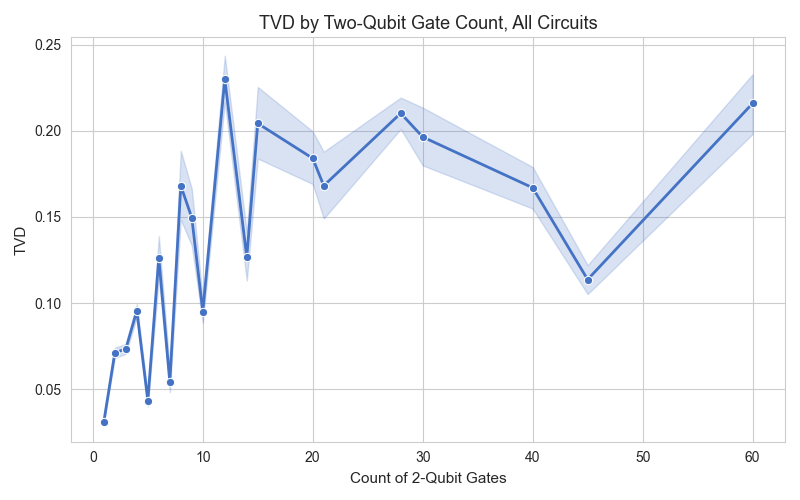

In [48]:
Image("../MATPLOTLIB_RESULTS/TVD by Two-Qubit Gate Count, All Circuits.png")

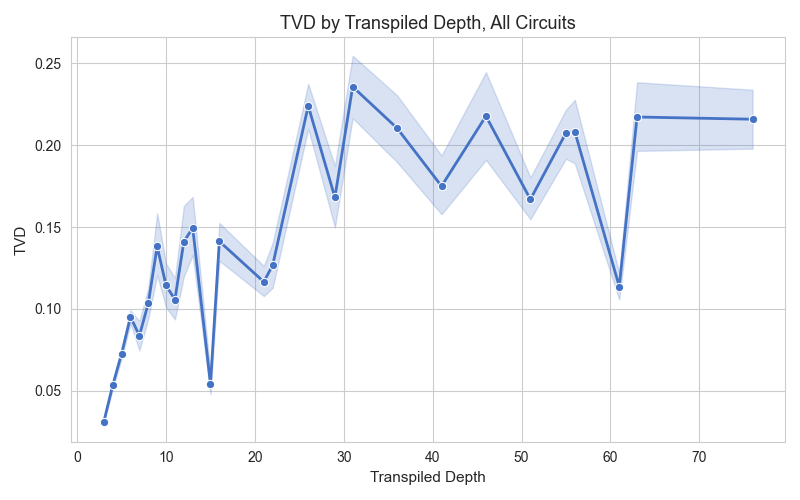

In [49]:
Image("../MATPLOTLIB_RESULTS/TVD by Transpiled Depth, All Circuits.png")

**Interpretation:** Qiskit's transpilation optimization level has a **weak effect** on both circuit depth and two-qubit gate count relative to the other causal variables - `circuit_name` and `num_qubits` are both substantially stronger causes of both mediators, with `optimization_level` accounting for a negligible share of the total causal influence on either. The "Transpiled Depth by Optimization Level" chart confirms this visually: only the Grover circuit shows any depth reduction across optimization levels (from ~35 at level 0 to ~30 at level 1), while all other circuits remain completely flat. The "Two-Qubit Gate Count by Optimization Level" chart is even clearer - no circuit shows any count_2q reduction across any optimization level. However, the "TVD by Transpiled Depth" and "TVD by Two-Qubit Gate Count" charts establish that both mediators genuinely matter for output quality when they do vary: TVD increases roughly from ~0.03 to ~0.22 as depth grows from 3 to 76, and a similar upward trend holds for count_2q - meaning that if optimization_level had reduced these mediators meaningfully, it would have translated into real TVD improvement. **Note:** this limited effect is likely specific to the simple, small circuits (2-5 qubits) tested here; for larger, more complex circuits, optimization level's effect would likely be more pronounced.

### Question 3: How does the number of shots affect the stability of the measured output distribution?

**Evidence components:**
1. `shots → tvd` arrow strength 
2. "TVD Stability by Shot Count, All Circuits" chart (diminishing returns direction)
3. `shots → tvd` edge in the causal graph (shown in cell 18 above)

In [50]:
print("Arrow strength for shots -> tvd:")
for (source, target), strength in ordered_tvd_strength.items():
    if source == 'shots':
        print(f"  shots -> tvd: {strength:.6f}")
        print(f"  (ranked last of {len(ordered_tvd_strength)} causes into tvd)")

Arrow strength for shots -> tvd:
  shots -> tvd: 0.000281
  (ranked last of 5 causes into tvd)


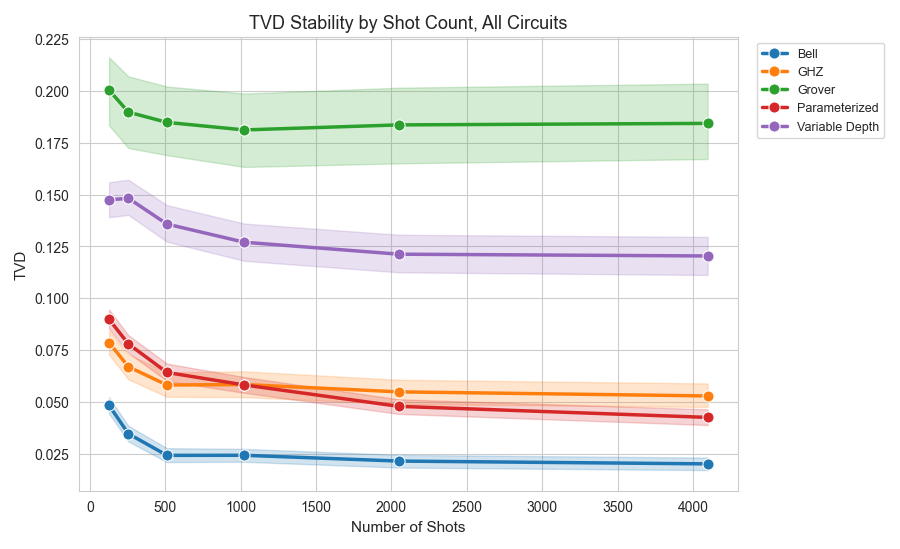

In [51]:
Image("../MATPLOTLIB_RESULTS/TVD Stability by Shot Count, All Circuits.png")

**Interpretation:** Shot count has the **weakest causal effect** on TVD of all five incoming causes - substantially weaker than noise_rate, depth, count_2q, and even num_qubits. However, the effect is real and directionally confirmed by both the causal graph edge and the "TVD Stability by Shot Count, All Circuits" chart, which shows TVD decreasing as shot count increases across all five circuit types. Critically, the relationship follows a **diminishing returns curve**: TVD drops noticeably from 100 to ~1000 shots, but past ~2000 shots the improvement becomes negligible regardless of circuit type. This means that while increasing shots does improve measurement stability, the gains beyond a moderate shot count are minimal - and shot count is far less impactful on output quality than noise rate or circuit depth.

### Question 4: Which has a stronger effect on output quality: circuit depth, two-qubit gate count, or simulated noise rate?

**Evidence components:** 
1) `ordered_tvd_strength` for all causes into `tvd` - directly compares the three variables in question.

In [52]:
print("Ranked causal influences on TVD:")
for i, ((source, target), strength) in enumerate(ordered_tvd_strength.items(), 1):
    print(f"    {i}) {source} -> {target}: {strength:.6f}")

top_source = list(ordered_tvd_strength.keys())[0][0]
print(f"\"{top_source}\" has the strongest causal effect on output quality (TVD).")

Ranked causal influences on TVD:
    1) noise_rate -> tvd: 0.012467
    2) depth -> tvd: 0.003748
    3) count_2q -> tvd: 0.002059
    4) num_qubits -> tvd: 0.000568
    5) shots -> tvd: 0.000281
"noise_rate" has the strongest causal effect on output quality (TVD).


**Interpretation:** Of the three variables in question, **noise_rate has the strongest causal effect on output quality (TVD)**, followed by depth, then count_2q - and the differences are substantial. noise_rate is meaningfully stronger than depth, which is itself stronger than count_2q. This ranking has a clear physical explanation: noise_rate directly perturbs qubit states during every gate operation, while depth and count_2q only *create opportunities* for that noise to accumulate. In other words, noise_rate is the root cause, while depth and count_2q are amplifiers - a deeper or more gate-heavy circuit under the same noise rate will produce worse TVD, but reducing depth or gate count can never fully compensate for high noise.

### Question 5: Can a simple causal graph help explain how quantum workflow configurations influence observed outcomes?

**Answer:** Yes - the causal graph successfully explains how quantum workflow configurations influence observed outcomes, and the results of this analysis provide three concrete pieces of confirming evidence. First, `optimization_level` was correctly predicted by the causal graph to have no direct edge to TVD - confirmed by the Q4 arrow strength output, where `optimization_level` does not appear anywhere in TVD's ranked causes, since its entire effect flows indirectly through `depth` and `count_2q`. Second, the graph correctly identified `noise_rate` as the strongest direct cause of TVD - confirmed quantitatively by the Q4 ranking. Third, the two-model split correctly captured that `success_probability` is conditionally defined by `circuit_name` - a design decision grounded in the causal graph's structure. Together, these findings validate that the causal graph built in Task 5 provides a principled and accurate framework for organizing and interpreting all five research questions about quantum workflow configurations, and how it influences observed outcomes.